In [2]:
import warnings
warnings.filterwarnings('ignore')

# Load Data

In [3]:
!gdown --id 1pYHvhzRYaolymRZYWmxFdylGOR-RgyWn #Download File

/usr/local/lib/python3.12/dist-packages/gdown/__main__.py:140: FutureWarning: Option `--id` was deprecated in version 4.3.1 and will be removed in 5.0. You don't need to pass it anymore to use a file ID.
  warnings.warn(
Downloading...
From: https://drive.google.com/uc?id=1pYHvhzRYaolymRZYWmxFdylGOR-RgyWn
To: /content/Rakamin Bootcamp - Dataset - Promotion Dataset.csv
100% 35.5k/35.5k [00:00<00:00, 56.3MB/s]


In [4]:
import pandas as pd

In [5]:
df = pd.read_csv('Rakamin Bootcamp - Dataset - Promotion Dataset.csv', sep = ';')
df.head()

,Employee_ID,Age,Years_at_Company,Performance_Score,Leadership_Score,Training_Hours,Projects_Handled,Peer_Review_Score,Current_Position_Level,Promotion_Eligible
0,EMP0001,24.0,21.0,2.0,44.0,42.0,19.0,61.0,Junior,0.0
1,EMP0002,50.0,8.0,5.0,45.0,66.0,11.0,6.0,Junior,0.0
2,EMP0003,56.0,9.0,5.0,19.0,96.0,6.0,86.0,Lead,0.0
3,EMP0004,39.0,24.0,4.0,51.0,16.0,6.0,52.0,Senior,0.0
4,EMP0005,41.0,NaN,4.0,64.0,57.0,16.0,59.0,Junior,0.0


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 10 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Employee_ID             1000 non-null   object 
 1   Age                     950 non-null    float64
 2   Years_at_Company        951 non-null    float64
 3   Performance_Score       950 non-null    float64
 4   Leadership_Score        950 non-null    float64
 5   Training_Hours          950 non-null    float64
 6   Projects_Handled        950 non-null    float64
 7   Peer_Review_Score       950 non-null    float64
 8   Current_Position_Level  950 non-null    object 
 9   Promotion_Eligible      950 non-null    float64
dtypes: float64(8), object(2)
memory usage: 78.3+ KB


# Handling Missing Value

In [7]:
# Imputasi missing value dengan median pada Age, Years_at_Company, dan Training_Hours
df['Age'].fillna(df['Age'].median(), inplace=True)
df['Years_at_Company'].fillna(df['Years_at_Company'].median(), inplace=True)
df['Training_Hours'].fillna(df['Training_Hours'].median(), inplace=True)

# Imputasi missing value dengan mean pada Performance_Score, Leadership_Score, Projects_Handled, dan Peer_Review_Score
df['Performance_Score'].fillna(df['Performance_Score'].mean(), inplace=True)
df['Leadership_Score'].fillna(df['Leadership_Score'].mean(), inplace=True)
df['Projects_Handled'].fillna(df['Projects_Handled'].mean(), inplace=True)
df['Peer_Review_Score'].fillna(df['Peer_Review_Score'].mean(), inplace=True)

# Imputasi missing value dengan modus pada Current_Position_Level
df['Current_Position_Level'].fillna(df['Current_Position_Level'].mode()[0], inplace=True)

# Drop baris yang memiliki missing value Promotion_Eligible
df.dropna(subset=['Promotion_Eligible'], inplace=True)

# Handling Data Type

In [8]:
df['Promotion_Eligible'] = df['Promotion_Eligible'].fillna(0).astype(int)
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 950 entries, 0 to 999
Data columns (total 10 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Employee_ID             950 non-null    object 
 1   Age                     950 non-null    float64
 2   Years_at_Company        950 non-null    float64
 3   Performance_Score       950 non-null    float64
 4   Leadership_Score        950 non-null    float64
 5   Training_Hours          950 non-null    float64
 6   Projects_Handled        950 non-null    float64
 7   Peer_Review_Score       950 non-null    float64
 8   Current_Position_Level  950 non-null    object 
 9   Promotion_Eligible      950 non-null    int64  
dtypes: float64(7), int64(1), object(2)
memory usage: 81.6+ KB


# Handling Outlier

In [9]:
num_cols = [
    'Age', 'Years_at_Company', 'Training_Hours',
    'Performance_Score', 'Leadership_Score',
    'Peer_Review_Score', 'Projects_Handled'
]

for col in num_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    # Menampilkan jumlah outlier
    outliers = ((df[col] < lower) | (df[col] > upper)).sum()
    print(f"{col}: {outliers} outlier(s) ditemukan")
    print(f"Range: [{lower}, {upper}]\n")

Age: 4 outlier(s) ditemukan
Range: [6.5, 74.5]

Years_at_Company: 2 outlier(s) ditemukan
Range: [-13.0, 43.0]

Training_Hours: 4 outlier(s) ditemukan
Range: [-87.0, 289.0]

Performance_Score: 0 outlier(s) ditemukan
Range: [-1.0, 7.0]

Leadership_Score: 0 outlier(s) ditemukan
Range: [-41.375, 141.625]

Peer_Review_Score: 0 outlier(s) ditemukan
Range: [-46.5, 149.5]

Projects_Handled: 0 outlier(s) ditemukan
Range: [-7.5, 28.5]



In [10]:
df_clean = df.copy()

# Kolom yang memiliki outliers
cols = ['Age', 'Years_at_Company', 'Training_Hours']

for col in cols:
    Q1 = df_clean[col].quantile(0.25)
    Q3 = df_clean[col].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    # Filter hanya nilai dalam batas
    df_clean = df_clean[(df_clean[col] >= lower_bound) & (df_clean[col] <= upper_bound)]

In [11]:
# Menghapus baris dengan anomali Years_at_Company = -5
df_clean = df_clean[df_clean['Years_at_Company'] != -5]

In [51]:
df_clean.describe()

,Age,Years_at_Company,Performance_Score,Leadership_Score,Training_Hours,Projects_Handled,Peer_Review_Score,Promotion_Eligible,Project_per_Years,Overall_Performance_Index
count,939.000000,939.000000,939.000000,939.000000,939.000000,939.000000,939.000000,939.000000,939.000000,939.000000
mean,40.700745,14.796592,2.962231,50.123986,100.701810,9.975284,51.005233,0.293930,1.203685,33.817281
std,10.701459,8.559596,1.389385,27.753353,56.458761,5.491168,28.179603,0.455803,1.789169,12.328283
min,10.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,5.946875
25%,32.000000,8.000000,2.000000,27.500000,54.000000,6.000000,27.000000,0.000000,0.358571,24.011364
50%,41.000000,15.000000,3.000000,50.117895,102.500000,10.000000,51.227368,0.000000,0.636364,33.732609
75%,49.000000,22.000000,4.000000,73.000000,147.000000,15.000000,76.000000,1.000000,1.153846,42.909375
max,59.000000,40.000000,5.000000,99.000000,199.000000,19.000000,99.000000,1.000000,19.000000,61.339544


# Option Feature Engineering

## Training Level

In [12]:
df_clean['Training_Level'] = pd.cut(df_clean['Training_Hours'],
                              bins=[0, 10, 30, 60, 100, float('inf')],
                              labels=['Very Low', 'Low', 'Moderate', 'High', 'Very High'])
# Display the counts for each segment
display(df_clean['Training_Level'].value_counts())

,count
Training_Level,
Very High,498
High,173
Moderate,129
Low,97
Very Low,39


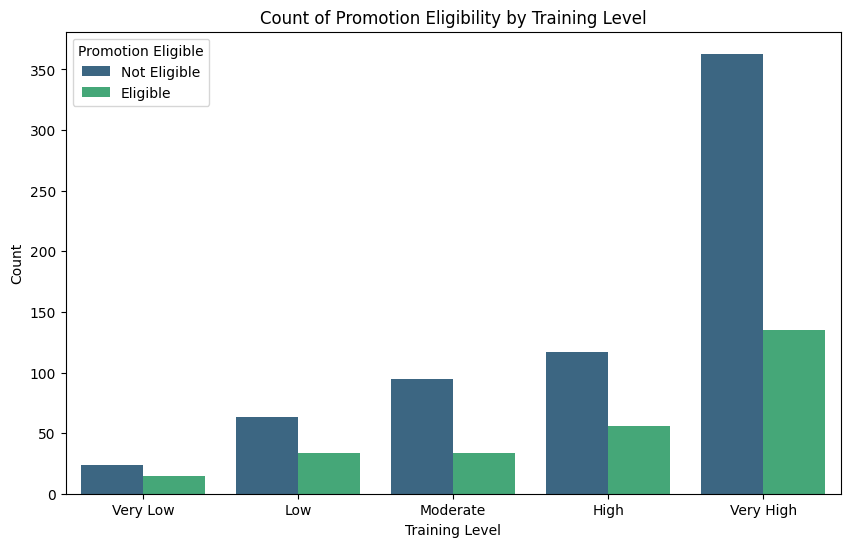

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6)) # Increased figure size for better readability
sns.countplot(data=df_clean, x='Training_Level', hue='Promotion_Eligible', palette='viridis')

plt.title('Count of Promotion Eligibility by Training Level')
plt.xlabel('Training Level')
plt.ylabel('Count')
plt.legend(title='Promotion Eligible', labels=['Not Eligible', 'Eligible']) # Swapped labels for clarity
plt.show()

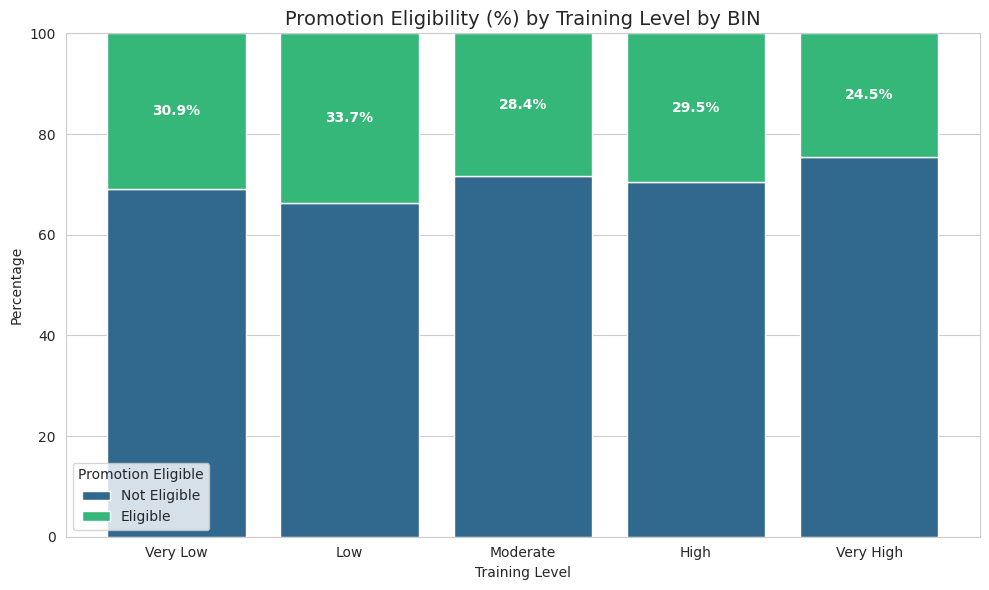

In [45]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd


# Hitung proporsi 100% per Training_Level
df_prop = (
    df_clean.groupby(['Training_Level', 'Promotion_Eligible'])
    .size()
    .reset_index(name='count')
)

df_total = df_prop.groupby('Training_Level')['count'].transform('sum')
df_prop['percent'] = (df_prop['count'] / df_total) * 100

# Plot dengan seaborn (pakai kind='bar' karena countplot tidak mendukung stacked langsung)
plt.figure(figsize=(10, 6))
sns.set_style("whitegrid")

# Untuk plot stacked, kita pivot dulu
df_pivot = df_prop.pivot(index='Training_Level', columns='Promotion_Eligible', values='percent').fillna(0)

# Warna dari viridis
colors = sns.color_palette("viridis", n_colors=len(df_pivot.columns))

# Plot manual stacked bar dengan seaborn palette
bottom = None
for i, col in enumerate(df_pivot.columns):
    plt.bar(
        df_pivot.index,
        df_pivot[col],
        bottom=bottom,
        color=colors[i],
        label='Eligible' if col == 1 else 'Not Eligible'
    )
    bottom = df_pivot[col] if bottom is None else bottom + df_pivot[col]

# Tambahkan label persentase di tengah bagian Eligible (asumsi Promotion_Eligible=1 adalah eligible)
for i in range(len(df_pivot)):
    eligible_val = df_pivot.loc[df_pivot.index[i], 1] if 1 in df_pivot.columns else 0
    not_eligible_val = df_pivot.loc[df_pivot.index[i], 0] if 0 in df_pivot.columns else 0
    plt.text(
        i,
        not_eligible_val + eligible_val / 2,
        f"{eligible_val:.1f}%",
        ha='center', va='center', color='white', fontweight='bold'
    )

# Format
plt.title('Promotion Eligibility (%) by Training Level by BIN', fontsize=14)
plt.xlabel('Training Level')
plt.ylabel('Percentage')
plt.ylim(0, 100)
plt.legend(title='Promotion Eligible', labels=['Not Eligible', 'Eligible'])
plt.tight_layout()
plt.show()

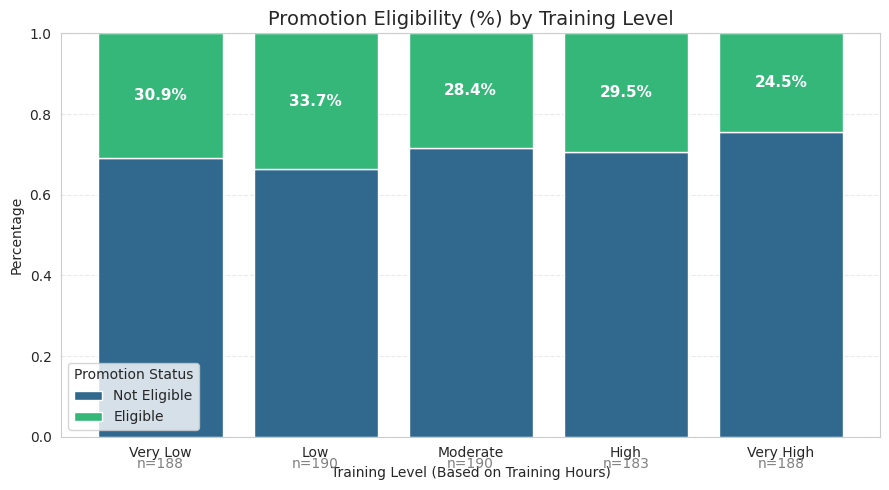

In [48]:
# --- Membuat Training_Level pakai qcut (otomatis bagi per kuartil) ---


df_clean['Training_Level'] = pd.qcut(
    df_clean['Training_Hours'],
    q=5,  # bagi menjadi 5 kelompok sama banyak
    labels=['Very Low', 'Low', 'Moderate', 'High', 'Very High']
)

# --- Hitung proporsi promotion per kategori ---
prop = (
    df_clean.groupby('Training_Level')['Promotion_Eligible']
    .value_counts(normalize=True)
    .rename('Proportion')
    .reset_index()
)

# --- Ubah ke format pivot untuk stacked bar ---
prop_pivot = prop.pivot(index='Training_Level', columns='Promotion_Eligible', values='Proportion').fillna(0)
prop_pivot = prop_pivot[[0, 1]]  # pastikan urut: Not Eligible, Eligible

# --- Hitung jumlah data per kategori ---
counts = df_clean['Training_Level'].value_counts().reindex(prop_pivot.index)

# --- Plot ---
plt.figure(figsize=(9, 5))
colors = sns.color_palette("viridis", 2)

# Bar Not Eligible
plt.bar(prop_pivot.index, prop_pivot[0], color=colors[0], label='Not Eligible')

# Bar Eligible (stacked di atasnya)
plt.bar(prop_pivot.index, prop_pivot[1], bottom=prop_pivot[0], color=colors[1], label='Eligible')

# Label % di tengah bagian Eligible
for i, val in enumerate(prop_pivot[1]):
    plt.text(i, prop_pivot[0].iloc[i] + val / 2, f"{val*100:.1f}%",
             ha='center', va='center', color='white', fontsize=11, fontweight='bold')

# Label jumlah data (n) di bawah batang
for i, total in enumerate(counts):
    plt.text(i, -0.05, f"n={total}", ha='center', va='top', fontsize=10, color='gray')

# --- Format dan tampilan ---
plt.title('Promotion Eligibility (%) by Training Level', fontsize=14)
plt.xlabel('Training Level (Based on Training Hours)')
plt.ylabel('Percentage')
plt.ylim(0, 1)
plt.legend(title='Promotion Status')
plt.grid(axis='y', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

In [50]:
print('Range Nilai Training_Hours')
pd.qcut(df_clean['Training_Hours'], q=5).value_counts(sort=False)

Range Nilai Training_Hours


,count
Training_Hours,
"(-0.001, 41.6]",188
"(41.6, 86.0]",190
"(86.0, 117.0]",190
"(117.0, 160.4]",183
"(160.4, 199.0]",188


## Leadership_Level

In [18]:
df_clean['Leadership_Level'] = pd.qcut(df_clean['Leadership_Score'], q=4, labels=['Low', 'Medium', 'High', 'Very High'])
display(df_clean['Leadership_Level'].value_counts())

,count
Leadership_Level,
Medium,252
Low,235
Very High,232
High,220


In [54]:
print('Range Nilai Leadership_Level')
pd.qcut(df_clean['Leadership_Score'], q=5).value_counts(sort=False)

Range Nilai Leadership_Level


,count
Leadership_Score,
"(-0.001, 21.0]",189
"(21.0, 43.2]",187
"(43.2, 59.0]",196
"(59.0, 78.0]",185
"(78.0, 99.0]",182


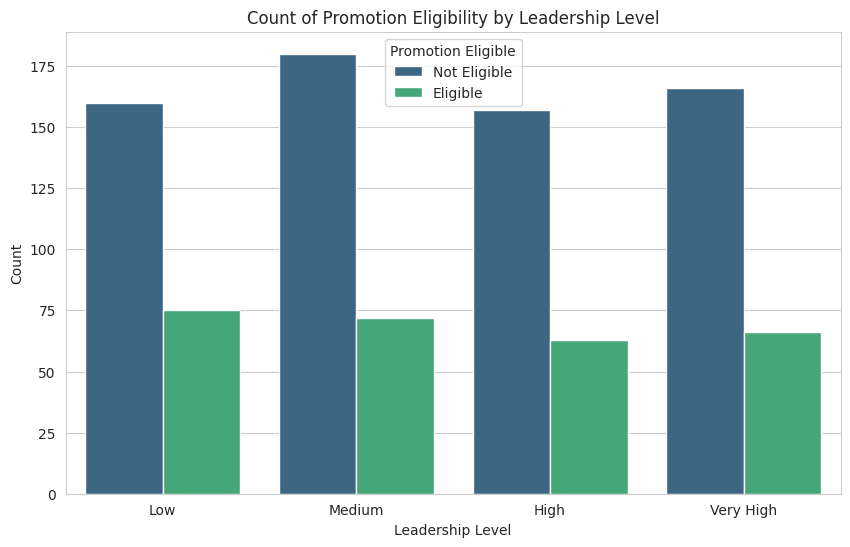

In [19]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.countplot(data=df_clean, x='Leadership_Level', hue='Promotion_Eligible', palette='viridis')

plt.title('Count of Promotion Eligibility by Leadership Level')
plt.xlabel('Leadership Level')
plt.ylabel('Count')
plt.legend(title='Promotion Eligible', labels=['Not Eligible', 'Eligible'])
plt.show()

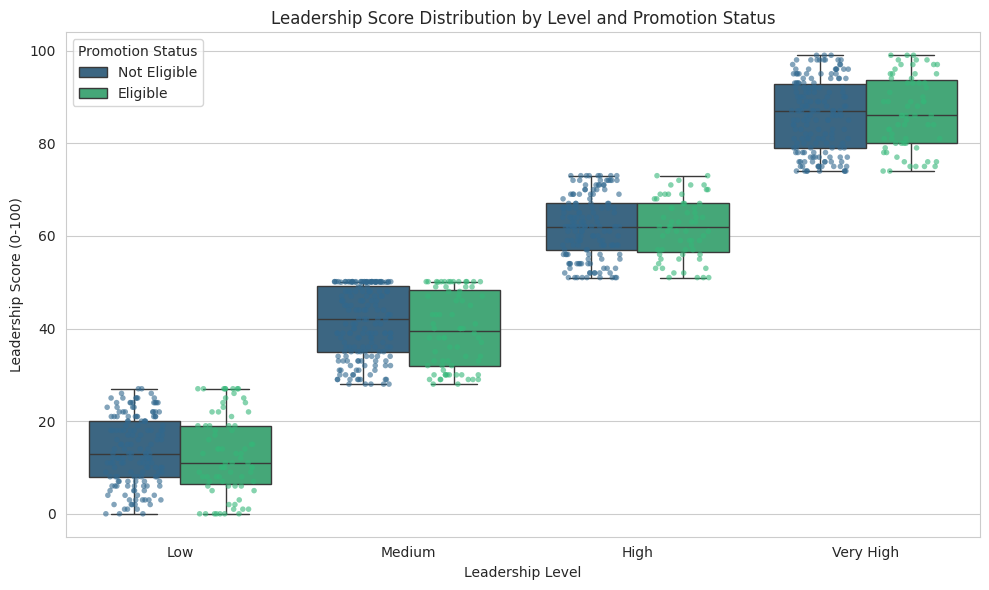

In [20]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.set_style("whitegrid")

# Boxplot: menunjukkan distribusi Leadership Score per level
sns.boxplot(
    data=df_clean,
    x='Leadership_Level',
    y='Leadership_Score',
    hue='Promotion_Eligible',
    palette='viridis',
    showfliers=False  # hilangkan outlier biar rapi
)

# Stripplot: overlay titik individual untuk menunjukkan sebaran
sns.stripplot(
    data=df_clean,
    x='Leadership_Level',
    y='Leadership_Score',
    hue='Promotion_Eligible',
    dodge=True,        # pisahkan titik antar kategori hue
    jitter=0.25,       # sebar titik biar tidak tumpuk
    palette='viridis',
    alpha=0.6,
    size=4,
    linewidth=0
)

# Hapus legenda duplikat
handles, labels = plt.gca().get_legend_handles_labels()
plt.legend(handles[0:2], ['Not Eligible', 'Eligible'], title='Promotion Status')

plt.title('Leadership Score Distribution by Level and Promotion Status')
plt.xlabel('Leadership Level')
plt.ylabel('Leadership Score (0-100)')
plt.tight_layout()
plt.show()

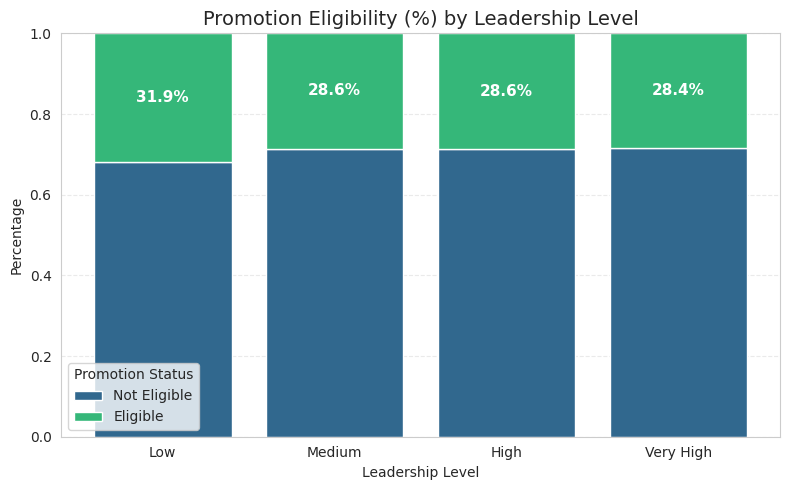

In [21]:
# --- Persiapan data ---
prop = (
    df_clean.groupby('Leadership_Level')['Promotion_Eligible']
    .value_counts(normalize=True)
    .rename('Proportion')
    .reset_index()
)

# Pivot agar jadi format wide (0/1 sebagai kolom)
prop_pivot = prop.pivot(index='Leadership_Level', columns='Promotion_Eligible', values='Proportion').fillna(0)
prop_pivot = prop_pivot[[0, 1]]  # pastikan urutan 0 dulu, lalu 1

# --- Visualisasi ---
plt.figure(figsize=(8, 5))
colors = sns.color_palette("viridis", 2)

# Bar untuk Not Eligible (0)
plt.bar(prop_pivot.index, prop_pivot[0], color=colors[0], label='Not Eligible')

# Bar untuk Eligible (1) ditumpuk di atas 0
plt.bar(prop_pivot.index, prop_pivot[1], bottom=prop_pivot[0], color=colors[1], label='Eligible')

# --- Tambahkan label % untuk Eligible ---
for idx, val in enumerate(prop_pivot[1]):
    total_height = prop_pivot.iloc[idx, 0] + val
    plt.text(
        idx,                        # posisi x
        prop_pivot.iloc[idx, 0] + val / 2,   # posisi y di tengah segmen eligible
        f"{val*100:.1f}%",          # label persentase
        ha='center', va='center', color='white', fontsize=11, fontweight='bold'
    )

# --- Styling ---
plt.title('Promotion Eligibility (%) by Leadership Level', fontsize=14)
plt.xlabel('Leadership Level')
plt.ylabel('Percentage')
plt.ylim(0, 1)
plt.legend(title='Promotion Status')
plt.grid(axis='y', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

## Project_Level


In [23]:
df_clean['Project_per_Years'] = df_clean['Projects_Handled'] / (df_clean['Years_at_Company'] + 1)

In [24]:
df_clean['Project_Level'] = pd.qcut(df_clean['Project_per_Years'],
                              q=4,
                              labels=['Low', 'Moderate', 'High', 'Very High'])

In [25]:
df_clean['Project_Level'].value_counts(normalize=True)


,proportion
Project_Level,
Moderate,0.251331
Low,0.250266
High,0.250266
Very High,0.248136


In [55]:
print('Range Nilai Project_Level')
pd.qcut(df_clean['Project_per_Years'], q=4).value_counts(sort=False)

Range Nilai Project_Level


,count
Project_per_Years,
"(-0.001, 0.359]",235
"(0.359, 0.636]",236
"(0.636, 1.154]",235
"(1.154, 19.0]",233


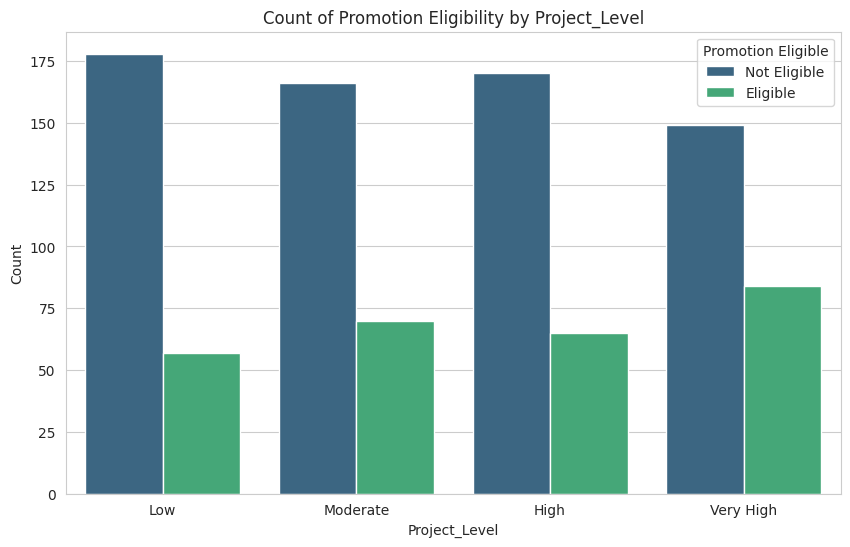

In [26]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.countplot(data=df_clean, x='Project_Level', hue='Promotion_Eligible', palette='viridis')

plt.title('Count of Promotion Eligibility by Project_Level')
plt.xlabel('Project_Level')
plt.ylabel('Count')
plt.legend(title='Promotion Eligible', labels=['Not Eligible', 'Eligible'])
plt.show()

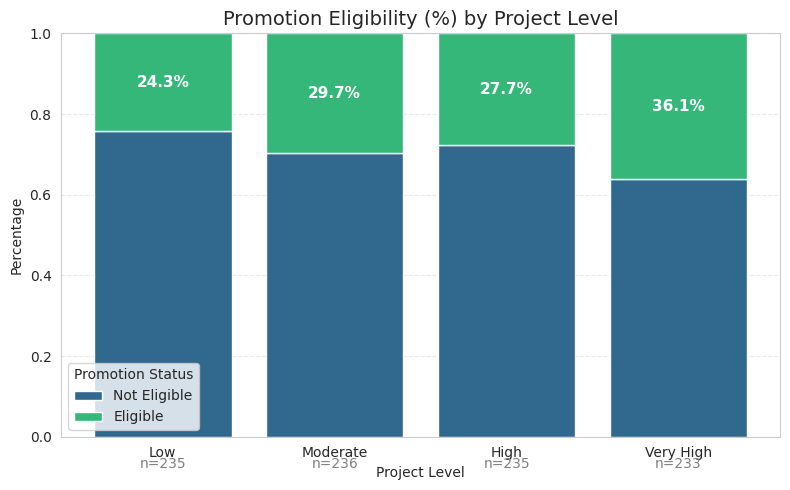

In [27]:
# Hitung proporsi promotion per kategori Project_Level
prop = (
    df_clean.groupby('Project_Level')['Promotion_Eligible']
    .value_counts(normalize=True)
    .rename('Proportion')
    .reset_index()
)

# Pivot agar 0 dan 1 jadi kolom
prop_pivot = prop.pivot(index='Project_Level', columns='Promotion_Eligible', values='Proportion').fillna(0)
prop_pivot = prop_pivot[[0, 1]]  # urutan 0 (Not Eligible), lalu 1 (Eligible)

# Hitung jumlah total per kategori (untuk label jumlah)
counts = df_clean['Project_Level'].value_counts().reindex(prop_pivot.index)

# --- Plot ---
plt.figure(figsize=(8, 5))
colors = sns.color_palette("viridis", 2)

# Bar Not Eligible
plt.bar(prop_pivot.index, prop_pivot[0], color=colors[0], label='Not Eligible')

# Bar Eligible di atasnya (stacked)
plt.bar(prop_pivot.index, prop_pivot[1], bottom=prop_pivot[0], color=colors[1], label='Eligible')

# Tambahkan label % di tengah segmen Eligible
for i, val in enumerate(prop_pivot[1]):
    plt.text(i, prop_pivot[0].iloc[i] + val / 2, f"{val*100:.1f}%",
             ha='center', va='center', color='white', fontsize=11, fontweight='bold')

# Tambahkan jumlah total di bawah tiap bar
for i, total in enumerate(counts):
    plt.text(i, -0.05, f"n={total}", ha='center', va='top', fontsize=10, color='gray')

# Styling
plt.title('Promotion Eligibility (%) by Project Level', fontsize=14)
plt.xlabel('Project Level')
plt.ylabel('Percentage')
plt.ylim(0, 1)
plt.legend(title='Promotion Status')
plt.grid(axis='y', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

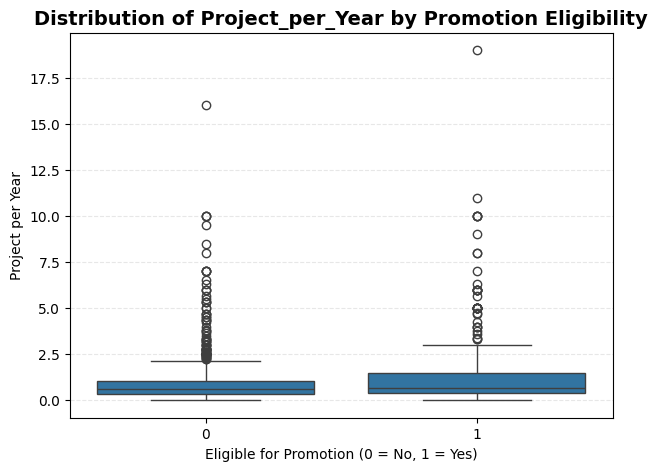

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(7,5))
sns.boxplot(
    x='Promotion_Eligible',
    y='Project_per_Years',
    data=df_clean,
    #palette={0:'#e74c3c', 1:'#2ecc71'} # Changed keys to integers 0 and 1
)

plt.title('Distribution of Project_per_Year by Promotion Eligibility', fontsize=14, weight='bold')
plt.xlabel('Eligible for Promotion (0 = No, 1 = Yes)')
plt.ylabel('Project per Year')
plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.show()

## Tenure Level



In [28]:
df_clean['Tenure_Level'] = pd.qcut( # Changed pd.cut to pd.qcut
    df_clean['Years_at_Company'],
    #bins=[0, 2, 5, 10, float('inf')],
    q = 4,
    labels=['New', 'Mid', 'Senior', 'Veteran']
)
df_clean['Tenure_Level'].value_counts()

,count
Tenure_Level,
New,256
Mid,253
Veteran,225
Senior,205


In [56]:
print('Range Nilai Tenure_Level')
pd.qcut(df_clean['Years_at_Company'], q=4).value_counts(sort=False)

Range Nilai Tenure_Level


,count
Years_at_Company,
"(-0.001, 8.0]",256
"(8.0, 15.0]",253
"(15.0, 22.0]",205
"(22.0, 40.0]",225


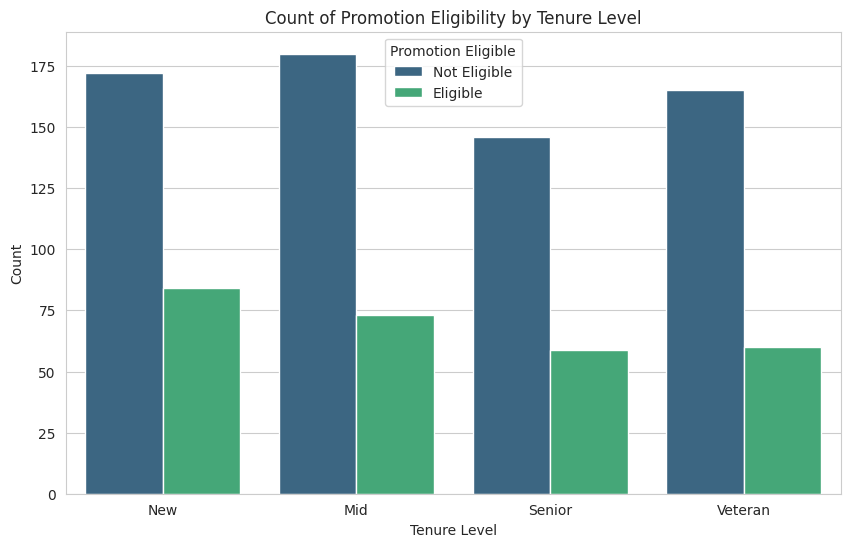

In [29]:
plt.figure(figsize=(10, 6))
sns.countplot(data=df_clean, x='Tenure_Level', hue='Promotion_Eligible', palette='viridis')

plt.title('Count of Promotion Eligibility by Tenure Level')
plt.xlabel('Tenure Level')
plt.ylabel('Count')
plt.legend(title='Promotion Eligible', labels=['Not Eligible', 'Eligible'])
plt.show()

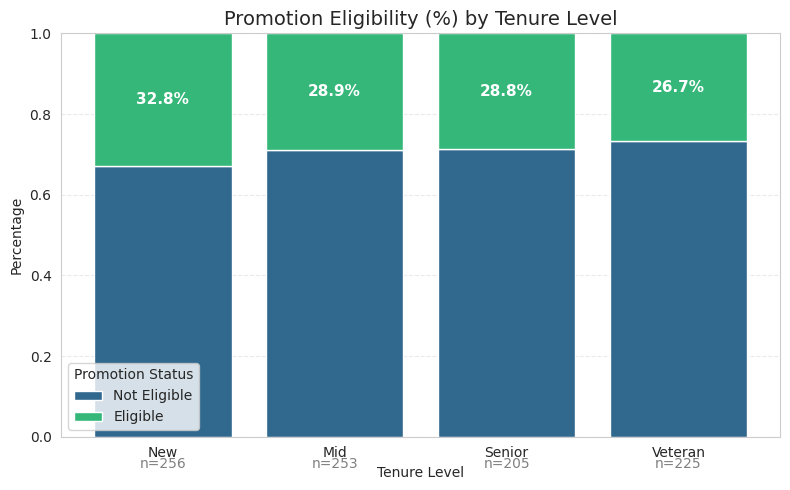

In [30]:
# Hitung proporsi promotion per kategori Tenure_Level
prop = (
    df_clean.groupby('Tenure_Level')['Promotion_Eligible']
    .value_counts(normalize=True)
    .rename('Proportion')
    .reset_index()
)

# Ubah jadi pivot (biar mudah di-plot)
prop_pivot = prop.pivot(index='Tenure_Level', columns='Promotion_Eligible', values='Proportion').fillna(0)
prop_pivot = prop_pivot[[0, 1]]  # urut: Not Eligible (0), Eligible (1)

# Hitung total data per kategori (untuk label "n=")
counts = df_clean['Tenure_Level'].value_counts().reindex(prop_pivot.index)

# --- Plot ---
plt.figure(figsize=(8, 5))
colors = sns.color_palette("viridis", 2)

# Bar bagian bawah: Not Eligible
plt.bar(prop_pivot.index, prop_pivot[0], color=colors[0], label='Not Eligible')

# Bar bagian atas: Eligible (stacked)
plt.bar(prop_pivot.index, prop_pivot[1], bottom=prop_pivot[0], color=colors[1], label='Eligible')

# Tambahkan label % di tengah bagian Eligible
for i, val in enumerate(prop_pivot[1]):
    plt.text(i, prop_pivot[0].iloc[i] + val / 2, f"{val*100:.1f}%",
             ha='center', va='center', color='white', fontsize=11, fontweight='bold')

# Tambahkan jumlah total (n) di bawah batang
for i, total in enumerate(counts):
    plt.text(i, -0.05, f"n={total}", ha='center', va='top', fontsize=10, color='gray')

# --- Format dan tampilan ---
plt.title('Promotion Eligibility (%) by Tenure Level', fontsize=14)
plt.xlabel('Tenure Level')
plt.ylabel('Percentage')
plt.ylim(0, 1)
plt.legend(title='Promotion Status')
plt.grid(axis='y', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

## Age Group

In [31]:
df_clean['Age_Group'] = pd.cut(df_clean['Age'],
                         bins=[20, 30, 40, 50, 60],
                         labels=['20s', '30s', '40s', '50s'])

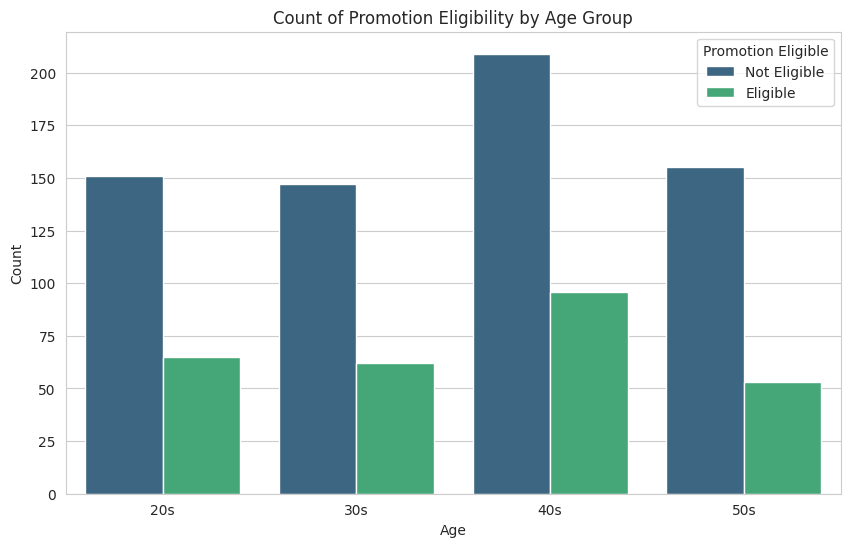

In [32]:
df_clean['Age_Group'] = pd.cut(df_clean['Age'],
                         bins=[20, 30, 40, 50, 60],
                         labels=['20s', '30s', '40s', '50s'])

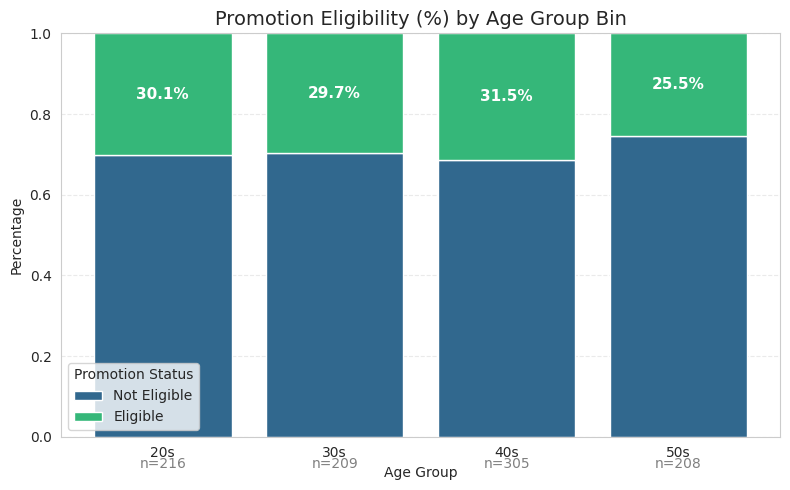

In [35]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Membuat kelompok usia (Age Group)
df_clean['Age_Group'] = pd.cut(
    df_clean['Age'],
    bins=[20, 30, 40, 50, 60],
    labels=['20s', '30s', '40s', '50s']
)

# Hitung proporsi promotion per kelompok usia
prop = (
    df_clean.groupby('Age_Group')['Promotion_Eligible']
    .value_counts(normalize=True)
    .rename('Proportion')
    .reset_index()
)

# Ubah ke format pivot untuk stacked bar
prop_pivot = prop.pivot(index='Age_Group', columns='Promotion_Eligible', values='Proportion').fillna(0)
prop_pivot = prop_pivot[[0, 1]]  # urutkan 0 = Not Eligible, 1 = Eligible

# Hitung total data per kelompok usia
counts = df_clean['Age_Group'].value_counts().reindex(prop_pivot.index)

# --- Plot ---
plt.figure(figsize=(8, 5))
colors = sns.color_palette("viridis", 2)

# Bar Not Eligible
plt.bar(prop_pivot.index, prop_pivot[0], color=colors[0], label='Not Eligible')

# Bar Eligible (stacked di atasnya)
plt.bar(prop_pivot.index, prop_pivot[1], bottom=prop_pivot[0], color=colors[1], label='Eligible')

# Label % di tengah bagian Eligible
for i, val in enumerate(prop_pivot[1]):
    plt.text(i, prop_pivot[0].iloc[i] + val / 2, f"{val*100:.1f}%",
             ha='center', va='center', color='white', fontsize=11, fontweight='bold')

# Label jumlah data (n) di bawah batang
for i, total in enumerate(counts):
    plt.text(i, -0.05, f"n={total}", ha='center', va='top', fontsize=10, color='gray')

# --- Tampilan akhir ---
plt.title('Promotion Eligibility (%) by Age Group Bin', fontsize=14)
plt.xlabel('Age Group')
plt.ylabel('Percentage')
plt.ylim(0, 1)
plt.legend(title='Promotion Status')
plt.grid(axis='y', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

In [57]:
print('Range Age_Group')
pd.qcut(df_clean['Age'], q=4).value_counts(sort=False)

Range Age_Group


,count
Age,
"(9.999, 32.0]",247
"(32.0, 41.0]",257
"(41.0, 49.0]",206
"(49.0, 59.0]",229


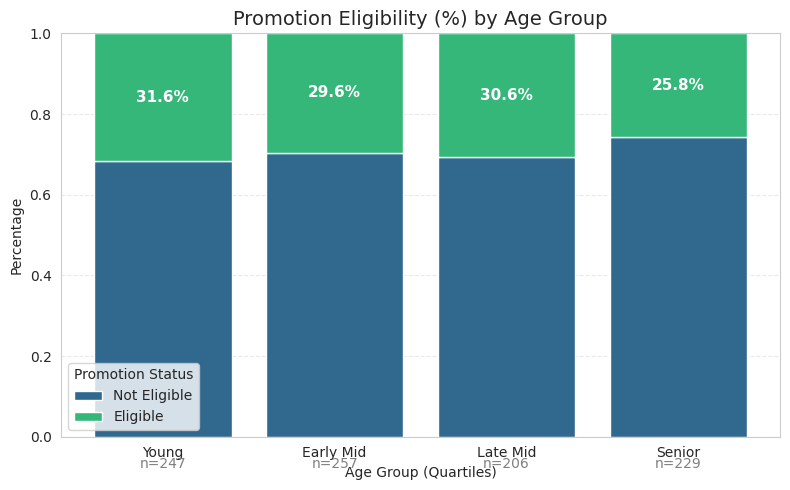

In [39]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Membuat Age_Group dengan qcut (pembagian berdasarkan kuartil data usia)
df_clean['Age_Group'] = pd.qcut(
    df_clean['Age'],
    q=4,  # bagi menjadi 4 grup
    labels=['Young', 'Early Mid', 'Late Mid', 'Senior']
)

# Hitung proporsi promotion per kelompok usia
prop = (
    df_clean.groupby('Age_Group')['Promotion_Eligible']
    .value_counts(normalize=True)
    .rename('Proportion')
    .reset_index()
)

# Ubah ke format pivot untuk stacked bar
prop_pivot = prop.pivot(index='Age_Group', columns='Promotion_Eligible', values='Proportion').fillna(0)
prop_pivot = prop_pivot[[0, 1]]  # urutkan kolom (0=Not Eligible, 1=Eligible)

# Hitung jumlah data per kelompok usia
counts = df_clean['Age_Group'].value_counts().reindex(prop_pivot.index)

# --- Plot ---
plt.figure(figsize=(8, 5))
colors = sns.color_palette("viridis", 2)

# Bar Not Eligible
plt.bar(prop_pivot.index, prop_pivot[0], color=colors[0], label='Not Eligible')

# Bar Eligible di atasnya (stacked)
plt.bar(prop_pivot.index, prop_pivot[1], bottom=prop_pivot[0], color=colors[1], label='Eligible')

# Tambahkan label % di tengah bagian Eligible
for i, val in enumerate(prop_pivot[1]):
    plt.text(i, prop_pivot[0].iloc[i] + val / 2, f"{val*100:.1f}%",
             ha='center', va='center', color='white', fontsize=11, fontweight='bold')

# Tambahkan jumlah data (n) di bawah batang
for i, total in enumerate(counts):
    plt.text(i, -0.05, f"n={total}", ha='center', va='top', fontsize=10, color='gray')

# --- Tampilan akhir ---
plt.title('Promotion Eligibility (%) by Age Group', fontsize=14)
plt.xlabel('Age Group (Quartiles)')
plt.ylabel('Percentage')
plt.ylim(0, 1)
plt.legend(title='Promotion Status')
plt.grid(axis='y', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

## Overall Performance Index

In [40]:
df_clean.columns

Index(['Employee_ID', 'Age', 'Years_at_Company', 'Performance_Score',
       'Leadership_Score', 'Training_Hours', 'Projects_Handled',
       'Peer_Review_Score', 'Current_Position_Level', 'Promotion_Eligible',
       'Training_Level', 'Leadership_Level', 'Project_per_Years',
       'Project_Level', 'Tenure_Level', 'Age_Group'],
      dtype='object')

In [41]:
from sklearn.preprocessing import MinMaxScaler

# Pastikan kolomnya ada:
cols = ['Performance_Score', 'Project_per_Years', 'Training_Hours',
        'Leadership_Score', 'Peer_Review_Score']

# Normalisasi 0–1
#scaler = MinMaxScaler()
# Apply scaler to df_clean since 'Project_per_Years' exists there
#df_clean[[col + '_norm' for col in cols]] = scaler.fit_transform(df_clean[cols])

# Buat Overall Performance Index (bobot bisa disesuaikan)
df_clean['Overall_Performance_Index'] = (
    0.20 * df_clean['Performance_Score'] +     # kinerja utama
    0.35 * df_clean['Project_per_Years'] +      # produktivitas
    0.20 * df_clean['Training_Hours'] +        # pengembangan diri
    0.10 * df_clean['Leadership_Score'] +      # kepemimpinan
    0.15 * df_clean['Peer_Review_Score']       # kerja sama
)

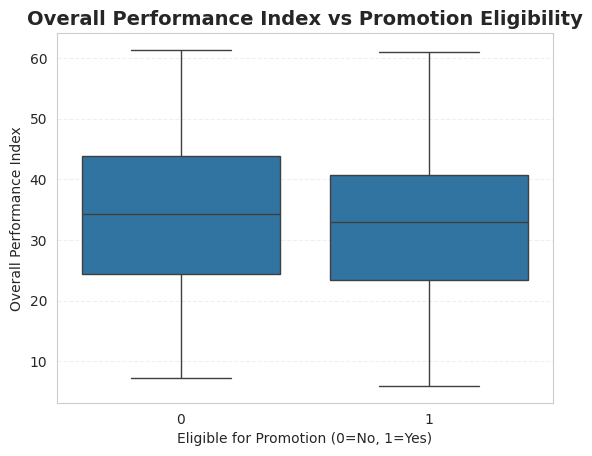

In [42]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.boxplot(
    x='Promotion_Eligible',
    y='Overall_Performance_Index',
    data=df_clean,
    #palette={0:'#e74c3c', 1:'#2ecc71'}
)
plt.title('Overall Performance Index vs Promotion Eligibility', fontsize=14, weight='bold')
plt.xlabel('Eligible for Promotion (0=No, 1=Yes)')
plt.ylabel('Overall Performance Index')
plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.show()

## Conclusion

Feature Engineering yang dimasukkan (data categorical-ordinal):


*   Training level: paling tinggi low (2nd)
*   Leadership level: ada perbedaan, level leadership rendah lebih besar promosinya
*   Project level : ada perbedaan, project level tinggi lebih besar promosinya
*   Tenure level: ada perbedaan,tenure lebih rendah lebih besar promosinya
*   Age group: lebih muda, lebih besar % promosinya

In [60]:
df_clean.head()

,Employee_ID,Age,Years_at_Company,Performance_Score,Leadership_Score,Training_Hours,Projects_Handled,Peer_Review_Score,Current_Position_Level,Promotion_Eligible,Training_Level,Leadership_Level,Project_per_Years,Project_Level,Tenure_Level,Age_Group,Overall_Performance_Index
0,EMP0001,24.0,21.0,2.0,44.0,42.0,19.0,61.0,Junior,0,Low,Medium,0.863636,High,Senior,Young,22.652273
1,EMP0002,50.0,8.0,5.0,45.0,66.0,11.0,6.0,Junior,0,Low,Medium,1.222222,Very High,New,Senior,20.027778
2,EMP0003,56.0,9.0,5.0,19.0,96.0,6.0,86.0,Lead,0,Moderate,Low,0.600000,Moderate,Mid,Senior,35.210000
3,EMP0004,39.0,24.0,4.0,51.0,16.0,6.0,52.0,Senior,0,Very Low,High,0.240000,Low,Veteran,Early Mid,16.984000
4,EMP0005,41.0,15.0,4.0,64.0,57.0,16.0,59.0,Junior,0,Low,High,1.000000,High,Mid,Early Mid,27.800000


In [68]:
df_clean.describe()

,Age,Years_at_Company,Performance_Score,Leadership_Score,Training_Hours,Projects_Handled,Peer_Review_Score,Promotion_Eligible,Project_per_Years,Overall_Performance_Index
count,939.000000,939.000000,939.000000,939.000000,939.000000,939.000000,939.000000,939.000000,939.000000,939.000000
mean,40.700745,14.796592,2.962231,50.123986,100.701810,9.975284,51.005233,0.293930,1.203685,33.817281
std,10.701459,8.559596,1.389385,27.753353,56.458761,5.491168,28.179603,0.455803,1.789169,12.328283
min,10.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,5.946875
25%,32.000000,8.000000,2.000000,27.500000,54.000000,6.000000,27.000000,0.000000,0.358571,24.011364
50%,41.000000,15.000000,3.000000,50.117895,102.500000,10.000000,51.227368,0.000000,0.636364,33.732609
75%,49.000000,22.000000,4.000000,73.000000,147.000000,15.000000,76.000000,1.000000,1.153846,42.909375
max,59.000000,40.000000,5.000000,99.000000,199.000000,19.000000,99.000000,1.000000,19.000000,61.339544


# Feature Transformation

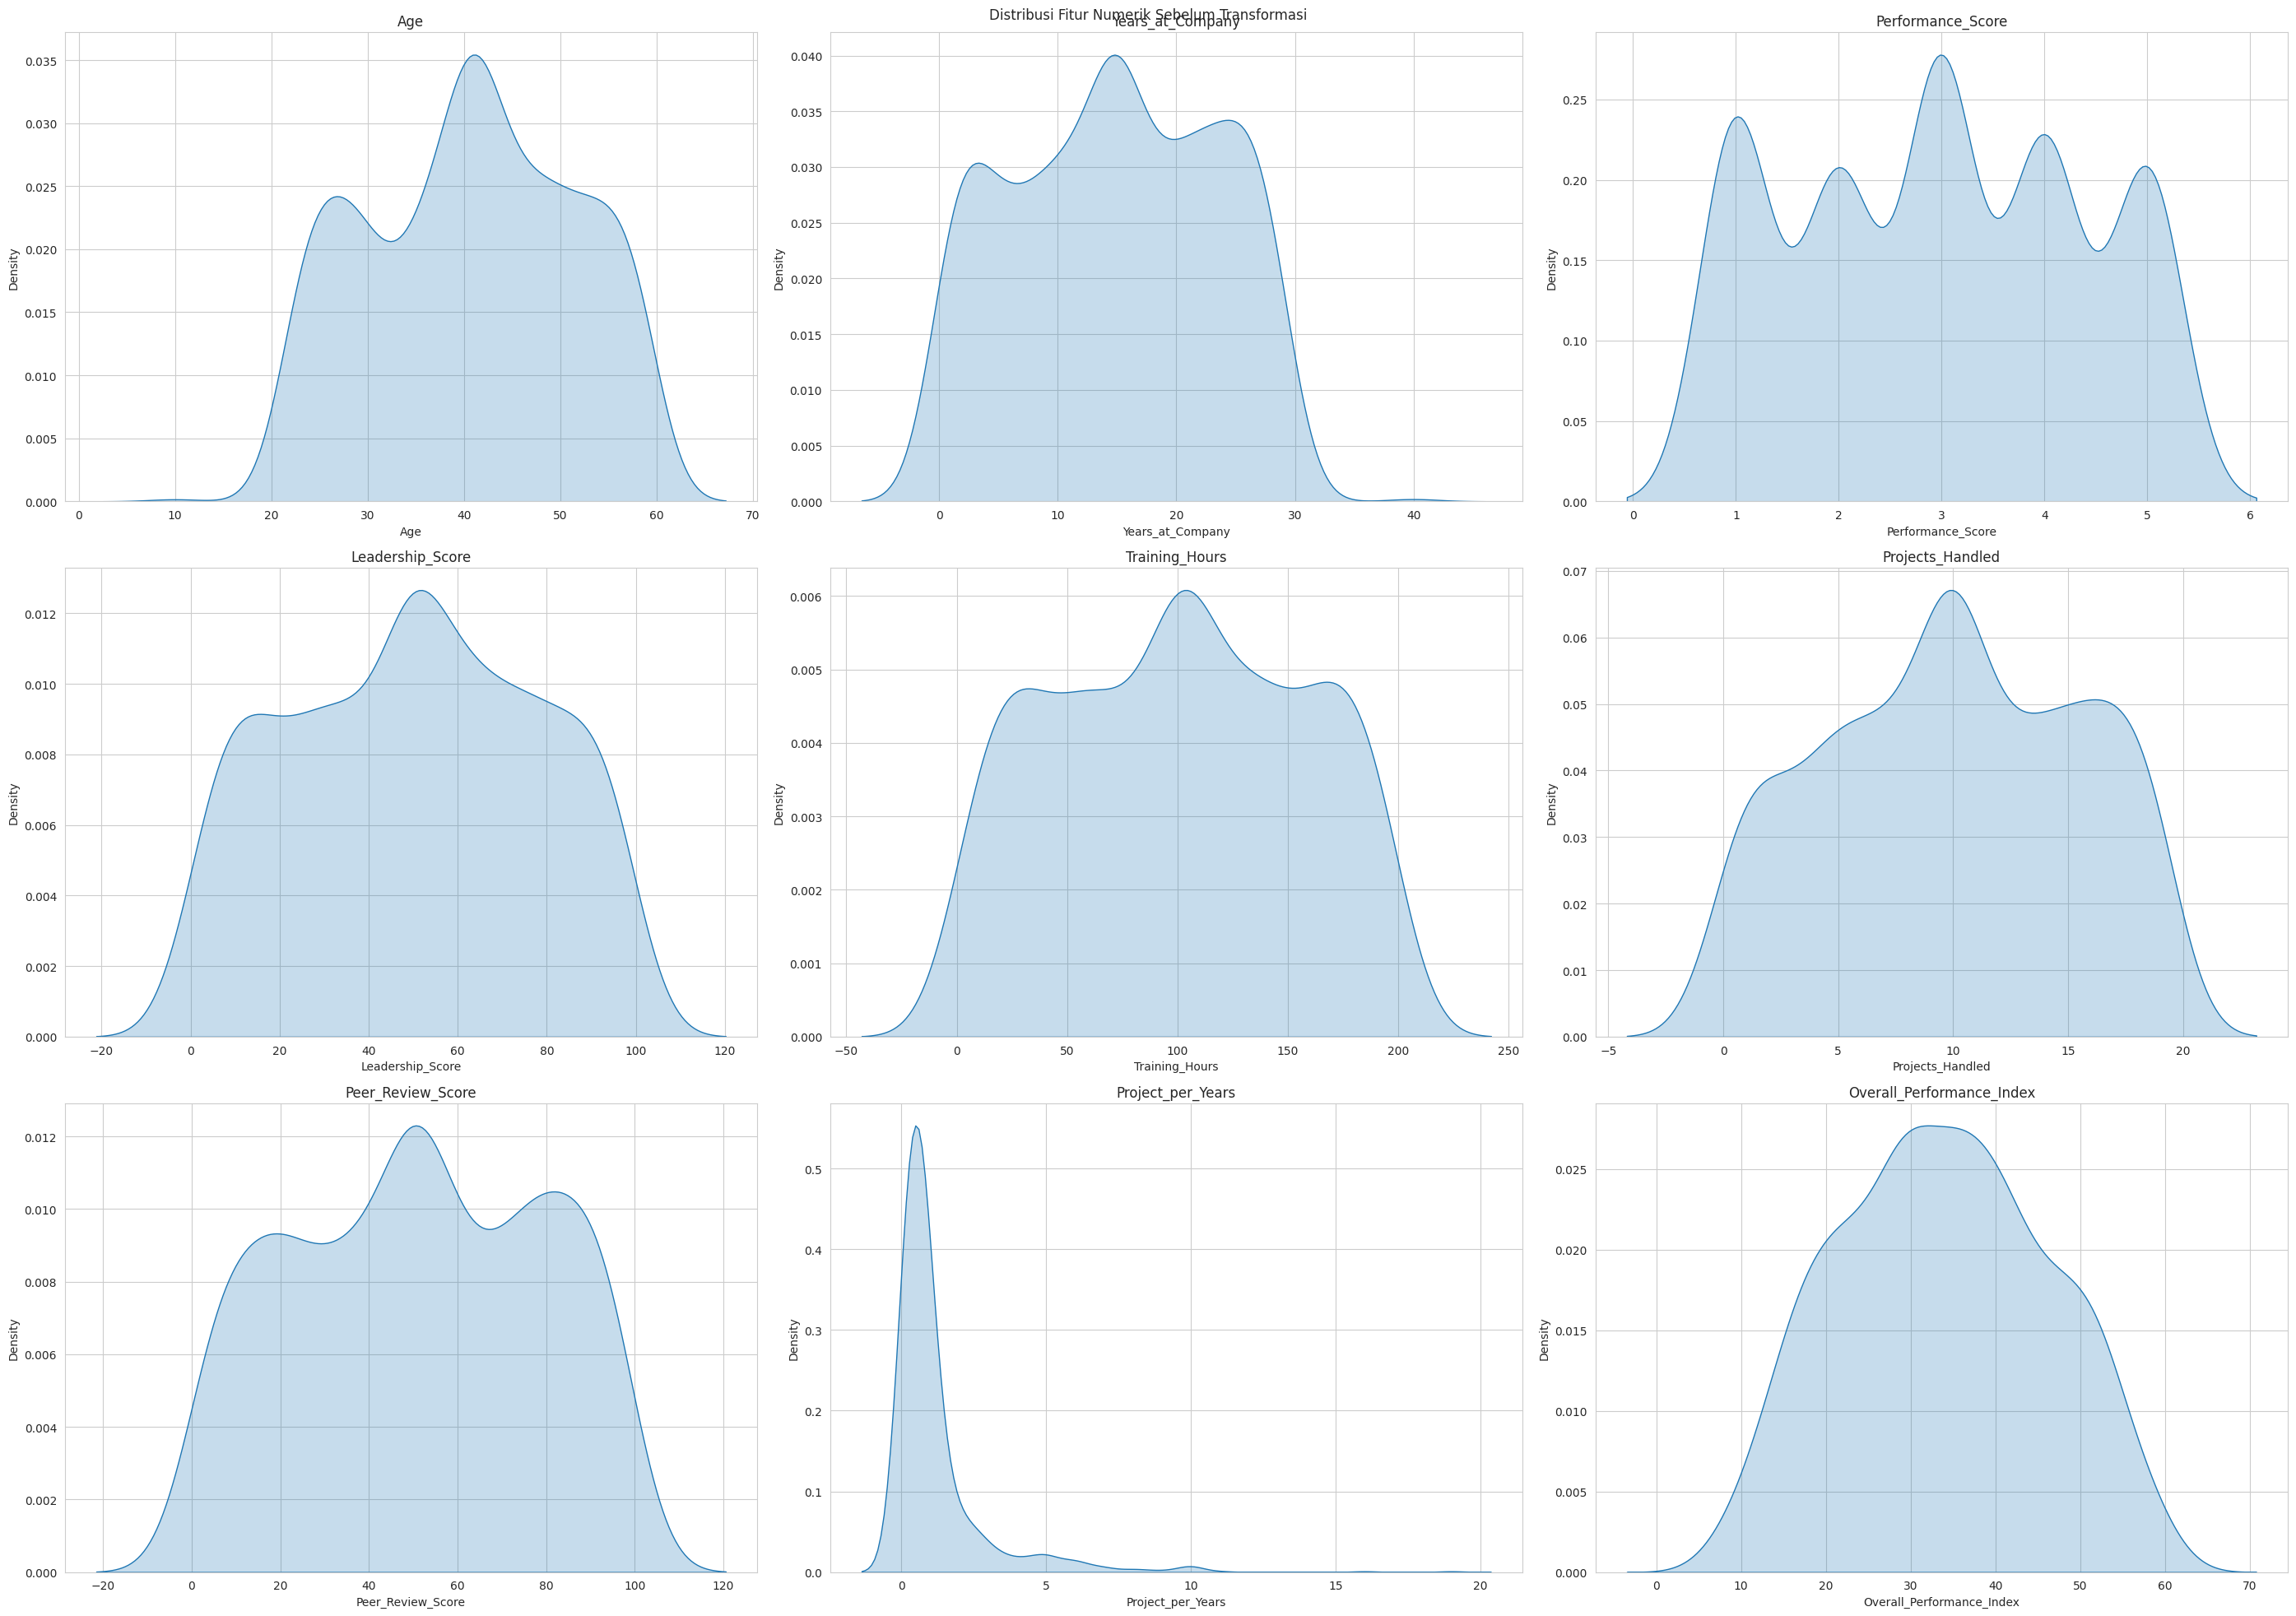

In [91]:
import matplotlib.pyplot as plt
import seaborn as sns

# Identifikasi tipe fitur
num_features = ['Age', 'Years_at_Company', 'Performance_Score','Leadership_Score', 'Training_Hours',
    'Projects_Handled', 'Peer_Review_Score', 'Project_per_Years', 'Overall_Performance_Index']
fig, axes = plt.subplots(3, 3, figsize=(28, 20))
axes=axes.flatten()
for i, col in enumerate (num_features):
    sns.kdeplot(data=df_clean, x=col, fill=True, ax=axes[i])
    axes[i].set_title (col)

#mhapus kolom yang tidak diperlukan
for j in range(i+1, len(axes)):
    fig.delaxes(axes[j])

plt.suptitle('Distribusi Fitur Numerik Sebelum Transformasi')


plt.tight_layout()
plt.show()

## Log Transformation


log transformasi untuk Age, Projecy_per_Years, dan Years_at_Company

In [99]:
import numpy as np
import pandas as pd
df_logtrans = df_clean.copy()

cols_to_log = ['Age', 'Years_at_Company', 'Project_per_Years']
cols_to_log = [c for c in cols_to_log if c in df_logtrans.columns]

df_logtrans[cols_to_log] = np.log1p(df_logtrans[cols_to_log])

## Standardisasi

In [100]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
df_scaled = df_logtrans.copy()

df_scaled[num_features] = scaler.fit_transform(df_logtrans[num_features])

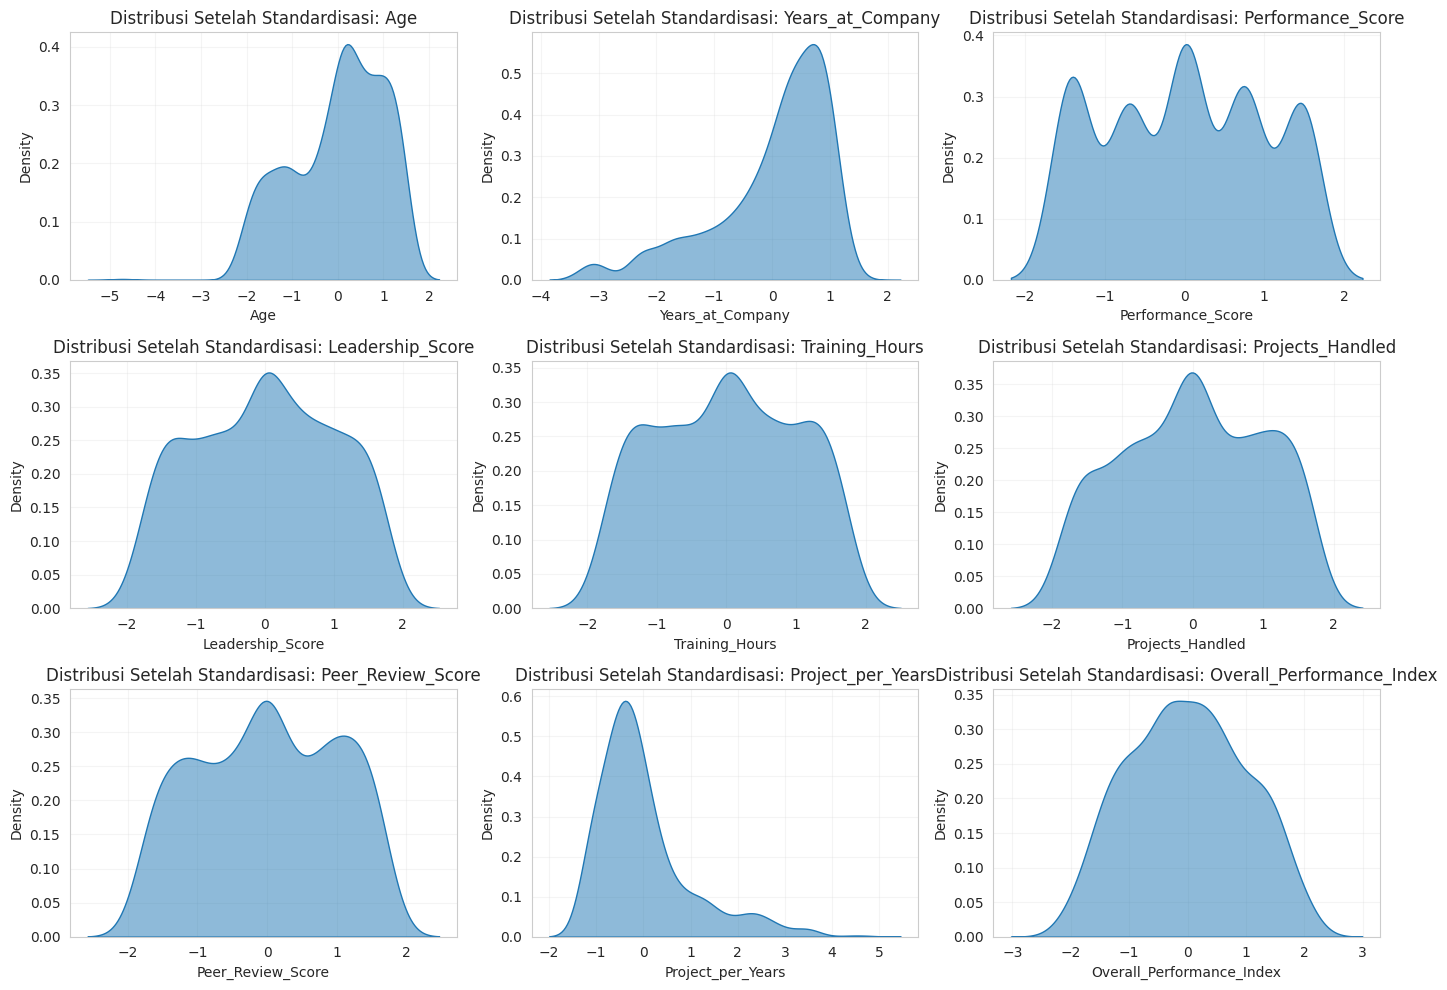

In [101]:
plt.figure(figsize=(14, 10))
for i, col in enumerate(num_features, 1):
    plt.subplot(3, 3, i)
    sns.kdeplot(df_scaled[col], fill=True, alpha=0.5)
    plt.title(f'Distribusi Setelah Standardisasi: {col}')
    plt.grid(alpha=0.2)

plt.tight_layout()
plt.show()

## One Hot Encoding

In [102]:
cat_features = [
    'Current_Position_Level',
    'Training_Level',
    'Leadership_Level',
    'Project_Level',
    'Tenure_Level',
    'Age_Group']

In [106]:
df_encoded = pd.get_dummies(df_scaled,
                            columns=cat_features,
                            drop_first=True)  # drop_first
print(df_encoded.shape)
df_encoded.head()

(939, 30)


,Employee_ID,Age,Years_at_Company,Performance_Score,Leadership_Score,Training_Hours,Projects_Handled,Peer_Review_Score,Promotion_Eligible,Project_per_Years,...,Leadership_Level_Very High,Project_Level_Moderate,Project_Level_High,Project_Level_Very High,Tenure_Level_Mid,Tenure_Level_Senior,Tenure_Level_Veteran,Age_Group_Early Mid,Age_Group_Late Mid,Age_Group_Senior
0,EMP0001,-1.730933,0.700183,-0.692928,-0.220775,-1.040283,1.644373,0.354870,0,-0.000999,...,False,False,True,False,False,True,False,False,False,False
1,EMP0002,0.862922,-0.395586,1.467452,-0.184724,-0.614968,0.186711,-1.597936,0,0.347126,...,False,False,False,True,False,False,False,False,False,True
2,EMP0003,1.267583,-0.266420,1.467452,-1.122047,-0.083323,-0.724327,1.242509,0,-0.302731,...,False,True,False,False,True,False,False,False,False,True
3,EMP0004,-0.020965,0.856900,0.747325,0.031581,-1.501042,-0.724327,0.035320,0,-0.806967,...,False,False,False,False,False,False,True,True,False,False
4,EMP0005,0.156543,0.309777,0.747325,0.500243,-0.774461,1.097750,0.283859,0,0.138699,...,False,False,True,False,True,False,False,True,False,False


## Imbalance Handling

### Split data

In [111]:
from sklearn.model_selection import train_test_split

X = df_encoded.drop(['Employee_ID','Promotion_Eligible','Overall_Performance_Index'], axis=1)
y = df_encoded['Promotion_Eligible']

X_train, X_test, y_train, y_test = train_test_split(X, y,test_size=0.2,stratify=y,random_state=42)

### Imbalance Check

In [112]:
print('Distribusi kelas sebelum balancing:')
print(y_train.value_counts())
print('\nProporsi kelas:')
print(y_train.value_counts(normalize=True))

Distribusi kelas sebelum balancing:
Promotion_Eligible
0    530
1    221
Name: count, dtype: int64

Proporsi kelas:
Promotion_Eligible
0    0.705726
1    0.294274
Name: proportion, dtype: float64


### SMOTE

In [114]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)
X_train_bal, y_train_bal = smote.fit_resample(X_train, y_train)

print('Setelah SMOTE:')
print(y_train_bal.value_counts())
print('\nProporsi kelas:')
print(y_train_bal.value_counts(normalize=True))

Setelah SMOTE:
Promotion_Eligible
1    530
0    530
Name: count, dtype: int64

Proporsi kelas:
Promotion_Eligible
1    0.5
0    0.5
Name: proportion, dtype: float64
